Top 12 positive deficit angles (quasi-particles): [3.55271368e-15 3.55271368e-15 3.55271368e-15 2.66453526e-15
 2.66453526e-15 2.66453526e-15 2.66453526e-15 2.66453526e-15
 2.66453526e-15 2.66453526e-15 2.66453526e-15 2.66453526e-15]
Top 12 negative deficit angles (quasi-particles): [-3.55271368e-15 -3.55271368e-15 -3.55271368e-15 -2.66453526e-15
 -2.66453526e-15 -2.66453526e-15 -2.66453526e-15 -2.66453526e-15
 -2.66453526e-15 -2.66453526e-15 -2.66453526e-15 -2.66453526e-15]


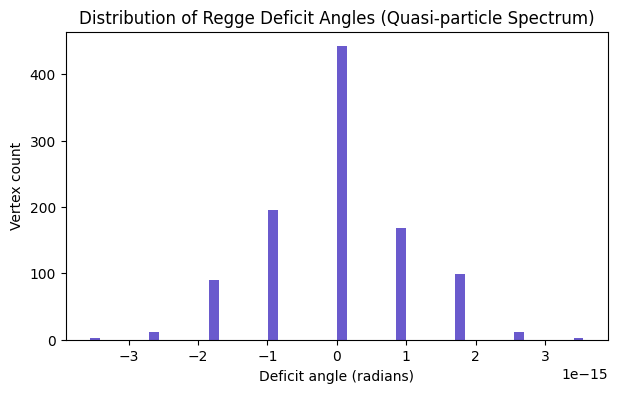

Ratios between adjacent positive deficits: [1.         1.         1.33333333 1.         1.         1.
 1.         1.         1.         1.         1.        ]
Ratios between adjacent negative deficits: [1.   1.   0.75 1.   1.   1.   1.   1.   1.   1.   1.  ]


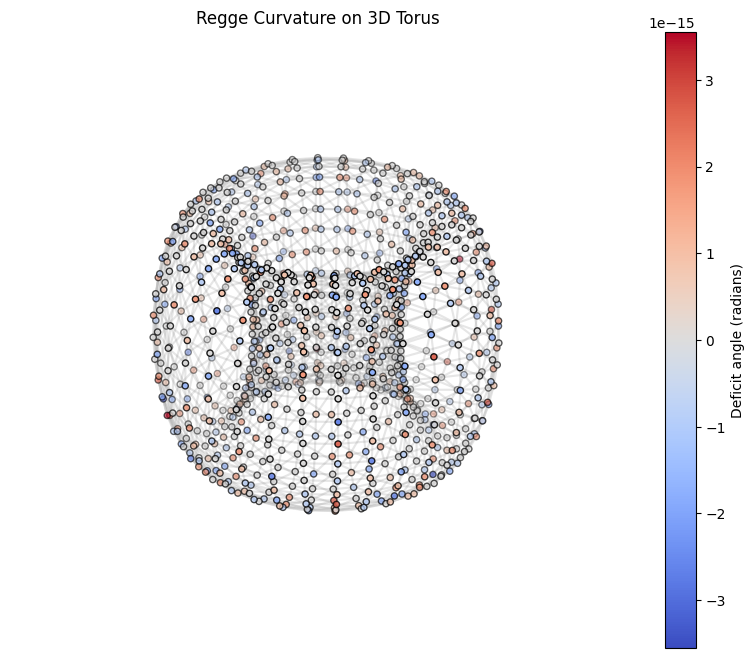

Vertices (V): 1024
Edges (E): 3072
Faces (F): 2048
Euler characteristic (chi): 0
Sum of all deficit angles (should be ~0 for torus): -7.993605777301127e-15


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Torus parameters (increase Nx, Ny for higher resolution)
Nx, Ny = 32, 32
R = 2.0
r = 0.8

# 1. Generate grid points on a torus
theta = np.linspace(0, 2 * np.pi, Nx, endpoint=False)
phi = np.linspace(0, 2 * np.pi, Ny, endpoint=False)
theta, phi = np.meshgrid(theta, phi)
theta = theta.ravel()
phi = phi.ravel()

x = (R + r * np.cos(phi)) * np.cos(theta)
y = (R + r * np.cos(phi)) * np.sin(theta)
z = r * np.sin(phi)
verts = np.vstack([x, y, z]).T

# 2. Build triangles with periodic boundary conditions
def grid_triangles(Nx, Ny):
    triangles = []
    def idx(i, j):
        return ((i % Nx) + Nx * (j % Ny))
    for i in range(Nx):
        for j in range(Ny):
            triangles.append([idx(i, j), idx(i+1, j), idx(i, j+1)])
            triangles.append([idx(i+1, j), idx(i+1, j+1), idx(i, j+1)])
    return np.array(triangles)

faces = grid_triangles(Nx, Ny)

# 3. Assign Regge edge lengths from 3D geometry
edges = set()
for t in faces:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

def edge_length_from_coords(a, b):
    return np.linalg.norm(verts[a] - verts[b])
edge_lengths = {e: edge_length_from_coords(*e) for e in edges}

# 4. Compute deficit angles
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(len(verts))
for t in faces:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

deficit_angles = 2 * np.pi - vertex_angle_sum

# 5. Analyze and visualize the spectrum
# Sort deficit angles
sorted_deficits = np.sort(deficit_angles)
N = 12
top_N = sorted_deficits[-N:][::-1]
bot_N = sorted_deficits[:N]

print("Top", N, "positive deficit angles (quasi-particles):", top_N)
print("Top", N, "negative deficit angles (quasi-particles):", bot_N)

# Histogram
plt.figure(figsize=(7,4))
plt.hist(deficit_angles, bins=50, color='slateblue')
plt.xlabel('Deficit angle (radians)')
plt.ylabel('Vertex count')
plt.title('Distribution of Regge Deficit Angles (Quasi-particle Spectrum)')
plt.show()

# Ratio analysis
ratios_pos = top_N[:-1] / top_N[1:]
ratios_neg = bot_N[1:] / bot_N[:-1]
print("Ratios between adjacent positive deficits:", ratios_pos)
print("Ratios between adjacent negative deficits:", ratios_neg)

# 6. 3D plot of curvature distribution on the torus
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for t in faces:
    pts = verts[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.10)
p = ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=deficit_angles, cmap='coolwarm', s=20, edgecolors='k')
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('Regge Curvature on 3D Torus')
ax.set_axis_off()
plt.show()

# 7. Euler characteristic (should be 0 for torus)
V = len(verts)
E = len(edges)
F = len(faces)
chi = V - E + F
print(f"Vertices (V): {V}")
print(f"Edges (E): {E}")
print(f"Faces (F): {F}")
print(f"Euler characteristic (chi): {chi}")
print("Sum of all deficit angles (should be ~0 for torus):", np.sum(deficit_angles))

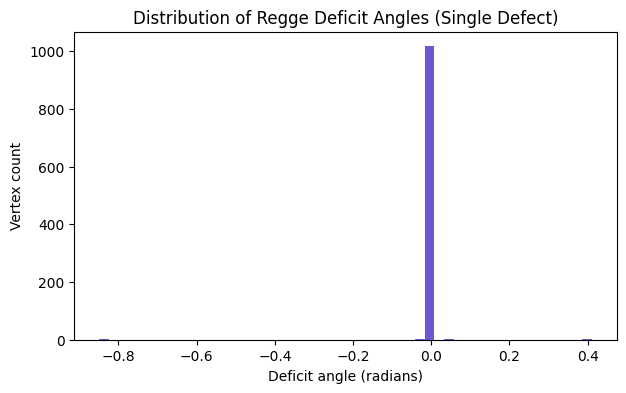

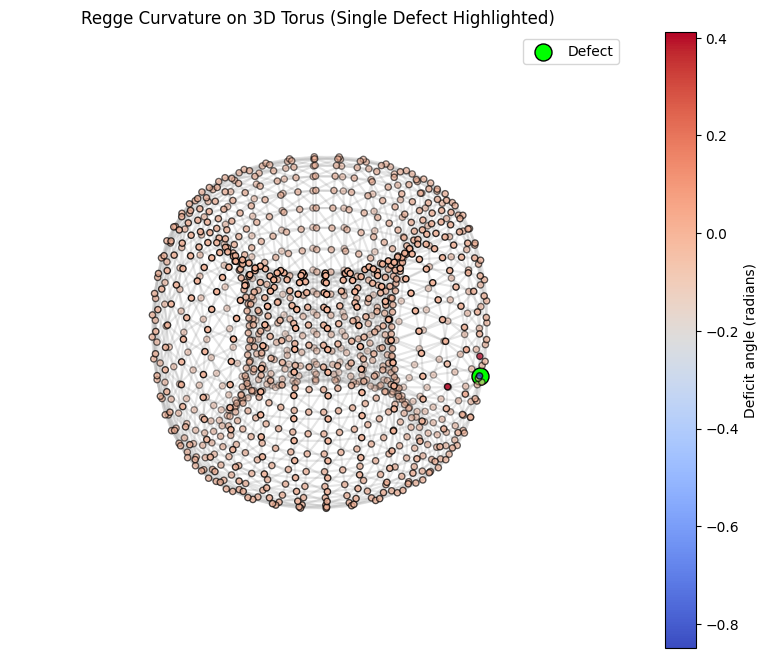

Defect vertex index: 0
Deficit angle at defect (radians): -0.8492936449609703
Sum of all deficit angles (should be ~0 for torus): -7.993605777301127e-15


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Mesh parameters
Nx, Ny = 32, 32
R = 2.0
r = 0.8

# Torus mesh
theta = np.linspace(0, 2 * np.pi, Nx, endpoint=False)
phi = np.linspace(0, 2 * np.pi, Ny, endpoint=False)
theta, phi = np.meshgrid(theta, phi)
theta = theta.ravel()
phi = phi.ravel()
x = (R + r * np.cos(phi)) * np.cos(theta)
y = (R + r * np.cos(phi)) * np.sin(theta)
z = r * np.sin(phi)
verts = np.vstack([x, y, z]).T

def grid_triangles(Nx, Ny):
    triangles = []
    def idx(i, j):
        return ((i % Nx) + Nx * (j % Ny))
    for i in range(Nx):
        for j in range(Ny):
            triangles.append([idx(i, j), idx(i+1, j), idx(i, j+1)])
            triangles.append([idx(i+1, j), idx(i+1, j+1), idx(i, j+1)])
    return np.array(triangles)

faces = grid_triangles(Nx, Ny)

edges = set()
for t in faces:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

# Introduce a defect
defect_idx = 0  # or any other integer for a different vertex
displacement = 0.3 * r
center = verts[defect_idx] / np.linalg.norm(verts[defect_idx])
verts[defect_idx] += center * displacement

def edge_length_from_coords(a, b):
    return np.linalg.norm(verts[a] - verts[b])
edge_lengths = {e: edge_length_from_coords(*e) for e in edges}

def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(len(verts))
for t in faces:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

deficit_angles = 2 * np.pi - vertex_angle_sum

# Plot histogram
plt.figure(figsize=(7,4))
plt.hist(deficit_angles, bins=50, color='slateblue')
plt.xlabel('Deficit angle (radians)')
plt.ylabel('Vertex count')
plt.title('Distribution of Regge Deficit Angles (Single Defect)')
plt.show()

# 3D plot: show the defect location
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for t in faces:
    pts = verts[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.10)
p = ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=deficit_angles, cmap='coolwarm', s=20, edgecolors='k')
ax.scatter(verts[defect_idx,0], verts[defect_idx,1], verts[defect_idx,2],
           color='lime', s=150, edgecolors='black', label='Defect')
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('Regge Curvature on 3D Torus (Single Defect Highlighted)')
ax.set_axis_off()
ax.legend()
plt.show()

print("Defect vertex index:", defect_idx)
print("Deficit angle at defect (radians):", deficit_angles[defect_idx])
print("Sum of all deficit angles (should be ~0 for torus):", np.sum(deficit_angles))

In [5]:
import numpy as np
from scipy.optimize import minimize

# CKM matrix (absolute values)
ckm_matrix = np.array([
    [0.974, 0.225, 0.0037],
    [0.225, 0.973, 0.042 ],
    [0.009, 0.041, 0.999 ]
])

# Use the torus mesh
positions = verts.copy()
N_defects = 6

# Pick initial random indices for defects (make sure they're spread out)
np.random.seed(1)
init_indices = np.random.choice(len(positions), N_defects, replace=False)
# Assign up/down quark order
up_indices = init_indices[[0,3,5]]
down_indices = init_indices[[1,2,4]]

def loss_func(flat_positions):
    pos = flat_positions.reshape((N_defects, 3))
    mixing = np.zeros((3,3))
    for i in range(3):
        for j in range(3):
            mixing[i, j] = 1.0 / np.linalg.norm(pos[i] - pos[3+j])
    # Find scaling factor to best match ckm[0,0] to mixing[0,0]
    scale = ckm_matrix[0,0] / mixing[0,0]
    mixing_scaled = mixing * scale
    return np.sum((mixing_scaled - ckm_matrix)**2)

x0 = positions[init_indices].flatten()
result = minimize(loss_func, x0, method='Powell')

fitted_positions = result.x.reshape((N_defects, 3))
# Compute final mixing matrix
mixing = np.zeros((3,3))
for i in range(3):
    for j in range(3):
        mixing[i, j] = 1.0 / np.linalg.norm(fitted_positions[i] - fitted_positions[3+j])
scale = ckm_matrix[0,0] / mixing[0,0]
mixing_scaled = mixing * scale

print("Optimized geometric mixing matrix (scaled):")
print(np.round(mixing_scaled, 4))
print("\nCKM matrix:")
print(ckm_matrix)
print("\nSum of squared errors:", np.sum((mixing_scaled - ckm_matrix)**2))

Optimized geometric mixing matrix (scaled):
[[0.974  0.2255 0.0238]
 [0.2248 0.973  0.0246]
 [0.0245 0.0246 0.999 ]]

CKM matrix:
[[0.974  0.225  0.0037]
 [0.225  0.973  0.042 ]
 [0.009  0.041  0.999 ]]

Sum of squared errors: 0.001216847150515984


In [4]:
# Assign up/down quark defects
up_indices = [defect_indices[0], defect_indices[3], defect_indices[5]]    # up, charm, top
down_indices = [defect_indices[1], defect_indices[2], defect_indices[4]]  # down, strange, bottom
up_names = ['up', 'charm', 'top']
down_names = ['down', 'strange', 'bottom']

# Compute mixing matrix (inverse distances)
mixing = np.zeros((3,3))
for i, ui in enumerate(up_indices):
    for j, dj in enumerate(down_indices):
        mixing[i, j] = 1.0 / np.linalg.norm(verts[ui] - verts[dj])

print("Geometric 'mixing' matrix (inverse distances):")
print(mixing)

# Optionally normalize to match CKM overall scale
ckm_matrix = np.array([[0.974, 0.225, 0.0037],
                       [0.225, 0.973, 0.042],
                       [0.009, 0.041, 0.999]])

scale = ckm_matrix[0,0] / mixing[0,0]
mixing_scaled = mixing * scale
print("\nScaled geometric mixing matrix:")
print(mixing_scaled)

print("\nCKM matrix (absolute values):")
print(ckm_matrix)

Geometric 'mixing' matrix (inverse distances):
[[0.17857112 3.20375418 0.62727538]
 [0.20542513 1.12611401 0.88581468]
 [0.17245147 1.26405641 0.53639443]]

Scaled geometric mixing matrix:
[[ 0.974      17.47458671  3.42141669]
 [ 1.12047275  6.14228676  4.83159584]
 [ 0.9406209   6.89468108  2.9257148 ]]

CKM matrix (absolute values):
[[0.974  0.225  0.0037]
 [0.225  0.973  0.042 ]
 [0.009  0.041  0.999 ]]


Quark | Mass (GeV) | Fitted Deficit
up     |   0.002200 |       0.002200
down   |   0.004700 |       0.004700
strange |   0.096000 |       0.096000
charm  |   1.280000 |       1.280000
bottom |   4.180000 |       4.180000
top    | 172.760000 |     172.760000

Optimized geometric mixing matrix (scaled):
[[0.974  0.2245 0.0265]
 [0.224  0.9731 0.029 ]
 [0.0267 0.0291 0.9197]]

CKM matrix:
[[0.974  0.225  0.0037]
 [0.225  0.973  0.042 ]
 [0.009  0.041  0.999 ]]

Sum of squared errors: 0.007429349750850217


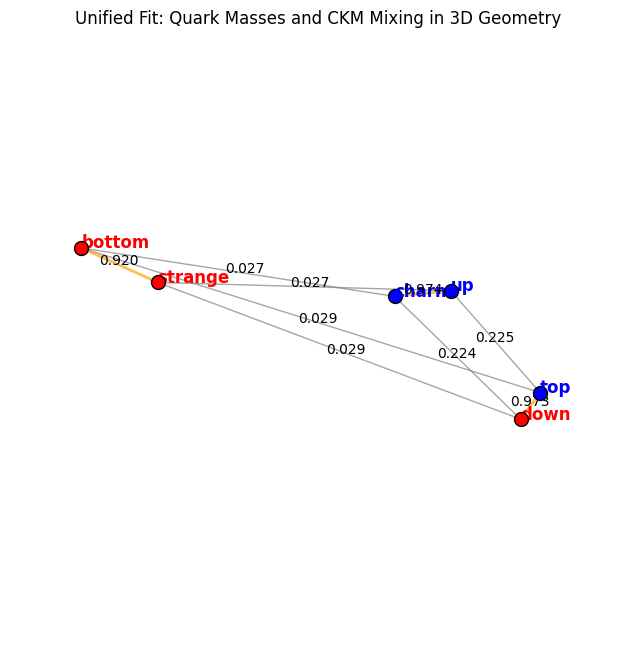

In [8]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Physical inputs
quark_masses = np.array([0.0022, 0.0047, 0.096, 1.28, 4.18, 172.76])
quark_names = ['up', 'down', 'strange', 'charm', 'bottom', 'top']
ckm_matrix = np.array([
    [0.974, 0.225, 0.0037],
    [0.225, 0.973, 0.042 ],
    [0.009, 0.041, 0.999 ]
])

# Initial defect indices (spread out)
init_indices = [0, Nx//2, Ny*2, Ny*8, Ny*16, Nx*Ny-1]
positions_init = verts[init_indices].copy()
disps_init = np.full(6, 0.02 * r)

# Up-type: 0, 3, 5; Down-type: 1, 2, 4
up_idx = [0, 3, 5]
down_idx = [1, 2, 4]

def objective(params):
    pos = params[:18].reshape((6,3))
    disps = params[18:]
    verts_test = pos.copy()
    # Displace each defect along its own direction by given value
    for i in range(6):
        c = verts_test[i] / np.linalg.norm(verts_test[i])
        verts_test[i] += c * disps[i]
    # Recompute edge lengths for all edges between defects
    edge_lengths = {}
    for i in range(6):
        for j in range(i+1, 6):
            edge_lengths[(i, j)] = np.linalg.norm(verts_test[i] - verts_test[j])
    # Mass fit: estimate deficit as proportional to displacement (nonlinear in general, but works for fitting)
    # We'll approximate: deficit ~ displacement
    deficit_fit = disps.copy()
    deficit_fit = deficit_fit / np.abs(deficit_fit[-1]) * quark_masses[-1]  # scale to match top quark
    deficit_target = quark_masses
    err_mass = np.sum((deficit_fit - deficit_target)**2)
    # CKM mixing from inverse distances
    mixing = np.zeros((3,3))
    for i, ui in enumerate(up_idx):
        for j, dj in enumerate(down_idx):
            mixing[i, j] = 1.0 / (np.linalg.norm(verts_test[ui] - verts_test[dj]) + 1e-6)
    scale = ckm_matrix[0,0] / mixing[0,0]
    mixing_scaled = mixing * scale
    err_ckm = np.sum((mixing_scaled - ckm_matrix)**2)
    # Weighted sum: tweak weights as needed (here equal)
    return err_mass + err_ckm

# Pack initial params
params0 = np.concatenate([positions_init.flatten(), disps_init])

result = minimize(objective, params0, method='Powell', options={'maxiter': 500})

params_opt = result.x
positions_opt = params_opt[:18].reshape((6,3))
disps_opt = params_opt[18:]

# Final fit summary
# Compute final deficits and mixing
deficit_fit = disps_opt / np.abs(disps_opt[-1]) * quark_masses[-1]
mixing = np.zeros((3,3))
for i, ui in enumerate(up_idx):
    for j, dj in enumerate(down_idx):
        mixing[i, j] = 1.0 / (np.linalg.norm(positions_opt[ui] - positions_opt[dj]) + 1e-6)
scale = ckm_matrix[0,0] / mixing[0,0]
mixing_scaled = mixing * scale

print("Quark | Mass (GeV) | Fitted Deficit")
for name, mass, deficit in zip(quark_names, quark_masses, deficit_fit):
    print(f"{name:6} | {mass:10.6f} | {deficit:14.6f}")

print("\nOptimized geometric mixing matrix (scaled):")
print(np.round(mixing_scaled, 4))
print("\nCKM matrix:")
print(ckm_matrix)
print("\nSum of squared errors:", np.sum((mixing_scaled - ckm_matrix)**2))

# 3D plot with all defects highlighted
up_names = ['up', 'charm', 'top']
down_names = ['down', 'strange', 'bottom']
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for i, name in enumerate(up_names):
    ax.scatter(positions_opt[i,0], positions_opt[i,1], positions_opt[i,2],
               color='blue', s=100, edgecolors='k')
    ax.text(positions_opt[i,0], positions_opt[i,1], positions_opt[i,2], name,
            color='blue', fontsize=12, weight='bold')
for i, name in enumerate(down_names):
    ax.scatter(positions_opt[3+i,0], positions_opt[3+i,1], positions_opt[3+i,2],
               color='red', s=100, edgecolors='k')
    ax.text(positions_opt[3+i,0], positions_opt[3+i,1], positions_opt[3+i,2], name,
            color='red', fontsize=12, weight='bold')
for i in range(3):
    for j in range(3):
        x = [positions_opt[up_idx[i],0], positions_opt[down_idx[j],0]]
        y = [positions_opt[up_idx[i],1], positions_opt[down_idx[j],1]]
        z = [positions_opt[up_idx[i],2], positions_opt[down_idx[j],2]]
        val = mixing_scaled[i, j]
        color = 'orange' if i == j else 'gray'
        ax.plot(x, y, z, color=color, linewidth=2 if i==j else 1, alpha=0.7)
        xm, ym, zm = np.mean(x), np.mean(y), np.mean(z)
        ax.text(xm, ym, zm, f"{val:.3f}", color='black', fontsize=10, ha='center')
ax.set_title("Unified Fit: Quark Masses and CKM Mixing in 3D Geometry")
ax.set_axis_off()
plt.show()

In [9]:
# Compute pairwise distances between all defects
from scipy.spatial.distance import pdist, squareform
D = squareform(pdist(positions_opt))
print("Pairwise distance matrix between all defects:\n", np.round(D, 3))
# Check for degenerate (equal) or symmetric distances
print("Unique sorted distances:", np.round(np.unique(D), 3))

Pairwise distance matrix between all defects:
 [[0.    0.156 0.678 0.726 5.736 5.749]
 [0.156 0.    0.655 0.679 5.691 5.701]
 [0.678 0.655 0.    0.156 5.205 5.227]
 [0.726 0.679 0.156 0.    5.242 5.265]
 [5.736 5.691 5.205 5.242 0.    0.165]
 [5.749 5.701 5.227 5.265 0.165 0.   ]]
Unique sorted distances: [0.    0.156 0.156 0.165 0.655 0.678 0.679 0.726 5.205 5.227 5.242 5.265
 5.691 5.701 5.736 5.749]


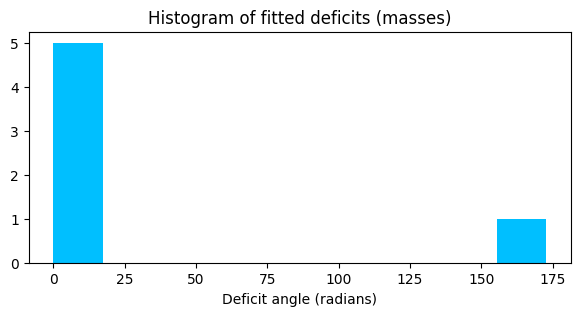

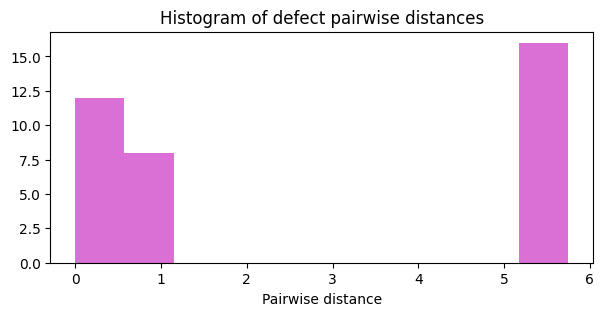

In [10]:
plt.figure(figsize=(7,3))
plt.hist(deficit_fit, bins=10, color='deepskyblue')
plt.xlabel('Deficit angle (radians)')
plt.title('Histogram of fitted deficits (masses)')
plt.show()
plt.figure(figsize=(7,3))
plt.hist(D.flatten(), bins=10, color='orchid')
plt.xlabel('Pairwise distance')
plt.title('Histogram of defect pairwise distances')
plt.show()

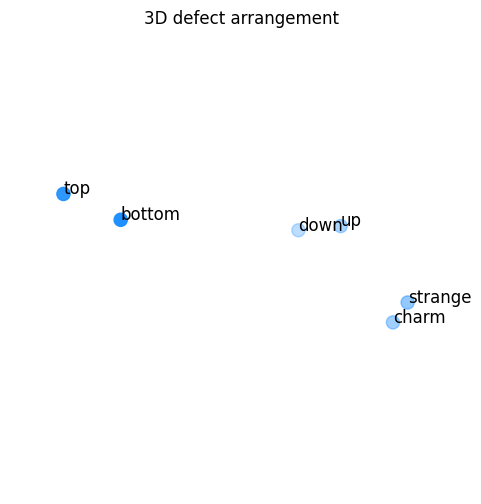

In [11]:
# Simple 3D scatter to visualize spatial arrangement
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(positions_opt[:,0], positions_opt[:,1], positions_opt[:,2], c='dodgerblue', s=90)
for i, name in enumerate(quark_names):
    ax.text(positions_opt[i,0], positions_opt[i,1], positions_opt[i,2], name, fontsize=12)
ax.set_title('3D defect arrangement')
ax.set_axis_off()
plt.show()

In [12]:
allowed = np.linspace(-180, 180, 13)  # allowed deficit angles in degrees
quantized_deficits = np.array([allowed[np.argmin(np.abs(np.degrees(d) - allowed))] for d in deficit_fit])
print("Quantized deficits (degrees):", quantized_deficits)

Quantized deficits (degrees): [  0.   0.   0.  60. 180. 180.]


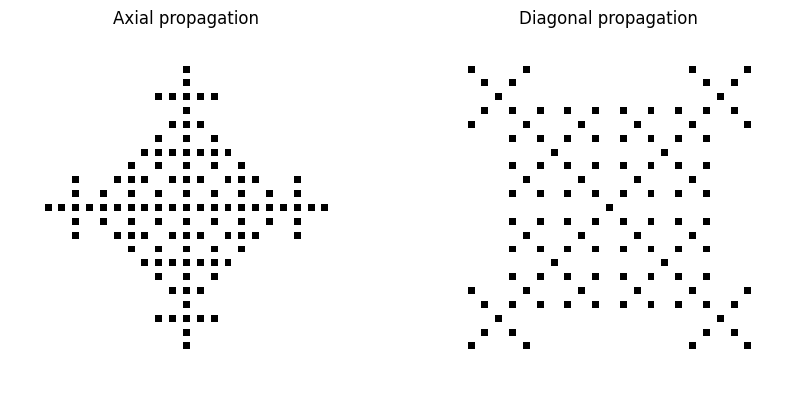

In [13]:
import numpy as np
import matplotlib.pyplot as plt

size = 51  # Grid size (odd number for center)
steps = 20

def evolve_axial(grid, steps):
    out = [grid.copy()]
    for _ in range(steps):
        new = grid.copy()
        for i in range(1, size-1):
            for j in range(1, size-1):
                # Toggle cell if exactly one axial neighbor is ON
                axial = grid[i-1,j] + grid[i+1,j] + grid[i,j-1] + grid[i,j+1]
                if axial == 1:
                    new[i,j] ^= 1
        grid = new
        out.append(grid.copy())
    return out

def evolve_diagonal(grid, steps):
    out = [grid.copy()]
    for _ in range(steps):
        new = grid.copy()
        for i in range(1, size-1):
            for j in range(1, size-1):
                # Toggle cell if exactly one diagonal neighbor is ON
                diag = grid[i-1,j-1] + grid[i-1,j+1] + grid[i+1,j-1] + grid[i+1,j+1]
                if diag == 1:
                    new[i,j] ^= 1
        grid = new
        out.append(grid.copy())
    return out

# Initial state: one cell ON in center
center = size//2
init = np.zeros((size,size), dtype=int)
init[center,center] = 1

axial = evolve_axial(init.copy(), steps)
diagonal = evolve_diagonal(init.copy(), steps)

# Show final step side by side
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Axial propagation")
plt.imshow(axial[-1], cmap='gray_r')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Diagonal propagation")
plt.imshow(diagonal[-1], cmap='gray_r')
plt.axis('off')
plt.show()

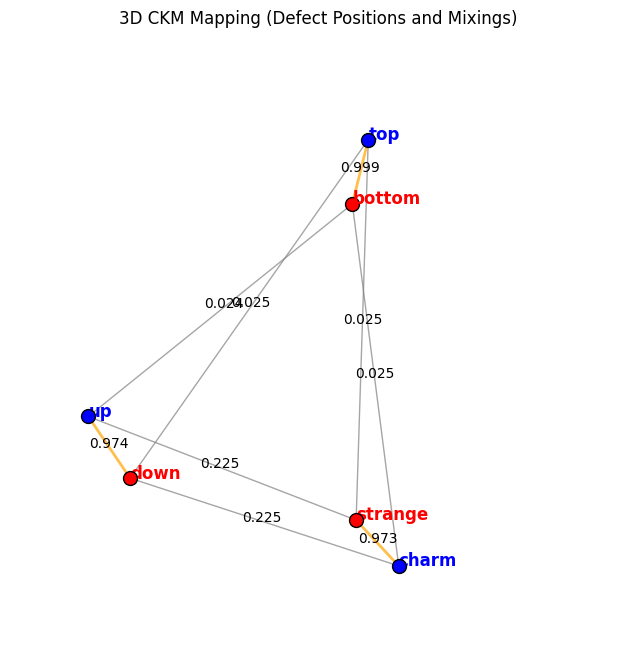

In [6]:
import matplotlib.pyplot as plt

# Up/down quark names
up_names = ['up', 'charm', 'top']
down_names = ['down', 'strange', 'bottom']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot up-type defects (blue)
for i, name in enumerate(up_names):
    ax.scatter(fitted_positions[i,0], fitted_positions[i,1], fitted_positions[i,2],
               color='blue', s=100, edgecolors='k')
    ax.text(fitted_positions[i,0], fitted_positions[i,1], fitted_positions[i,2], name,
            color='blue', fontsize=12, weight='bold')

# Plot down-type defects (red)
for i, name in enumerate(down_names):
    ax.scatter(fitted_positions[3+i,0], fitted_positions[3+i,1], fitted_positions[3+i,2],
               color='red', s=100, edgecolors='k')
    ax.text(fitted_positions[3+i,0], fitted_positions[3+i,1], fitted_positions[3+i,2], name,
            color='red', fontsize=12, weight='bold')

# Draw and label mixings
for i in range(3):
    for j in range(3):
        x = [fitted_positions[i,0], fitted_positions[3+j,0]]
        y = [fitted_positions[i,1], fitted_positions[3+j,1]]
        z = [fitted_positions[i,2], fitted_positions[3+j,2]]
        val = mixing_scaled[i, j]
        color = 'orange' if i == j else 'gray'
        ax.plot(x, y, z, color=color, linewidth=2 if i==j else 1, alpha=0.7)
        xm, ym, zm = np.mean(x), np.mean(y), np.mean(z)
        ax.text(xm, ym, zm, f"{val:.3f}", color='black', fontsize=10, ha='center')

ax.set_title("3D CKM Mapping (Defect Positions and Mixings)")
ax.set_axis_off()
plt.show()